In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import random
from scipy.sparse import csr_matrix, csc_matrix
from scipy.io import mmread
from scipy.stats import mannwhitneyu

In [18]:
import loompy as lp

In [3]:
sc.logging.print_header()
sc.settings.set_figure_params(dpi_save=600, facecolor='white', fontsize=7, format='pdf')

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 louvain==0.8.1 pynndescent==0.5.13


In [4]:
random.seed(71444)

In [5]:
ad.logging.print_memory_usage()

Memory usage: current 0.55 GB, difference +0.55 GB


In [6]:
outdir = '/cluster/home/chenyulong/GSE165816/0.1out'
os.chdir(outdir)

In [7]:
adata=sc.read_h5ad('./Final_Fib.h5ad')

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
print(adata.X.shape)

(13214, 4000)


In [9]:
print(adata.raw.X.shape)

(13214, 24196)


In [11]:
adata_raw = adata.raw.to_adata() 

In [12]:
gene_names = np.array(adata_raw.var_names)
cell_names = np.array(adata_raw.obs_names)

if isinstance(adata_raw.X, csr_matrix):
    expr_matrix = adata_raw.X.toarray()
else:
    expr_matrix = np.array(adata_raw.X)

df = pd.DataFrame(expr_matrix, index=cell_names, columns=gene_names)

In [13]:
df = df[df.columns.intersection(adata.var_names)]

In [14]:
print(df.shape)

(13214, 4000)


In [15]:
expr_matrix = df.values.T  

In [16]:
print(expr_matrix.shape)

(4000, 13214)


In [19]:
row_attrs = {"Gene": np.array(df.columns)}
col_attrs = {"CellID": np.array(df.index)}

lp.create(
    "adata_pyscenic.loom",
    expr_matrix,  
    row_attrs,
    col_attrs
)

In [20]:
import h5py

scenic_file = "/cluster/home/chenyulong/GSE165816/pySCENIC/adata_pyscenic_SCENIC.loom"

with h5py.File(scenic_file, "r") as f:
    print("Keys in file:", list(f.keys()))  
    print("Attributes in file:", dict(f.attrs)) 
    print("Row attributes:", list(f["row_attrs"].keys()))  
    print("Column attributes:", list(f["col_attrs"].keys()))  


Keys in file: ['attrs', 'col_attrs', 'col_graphs', 'layers', 'matrix', 'row_attrs', 'row_graphs']
Attributes in file: {'last_modified': '20250326T092923.894982Z'}
Row attributes: ['Gene', 'Regulons']
Column attributes: ['CellID', 'RegulonsAUC']


In [21]:
scenic_file = "/cluster/home/chenyulong/GSE165816/pySCENIC/adata_pyscenic_SCENIC.loom"

with h5py.File(scenic_file, "r") as f:
    regulons_raw = f["row_attrs/Regulons"][:]

regulons = [name for name, _ in regulons_raw.dtype.descr]

print(regulons)  

['BCL6(+)', 'CEBPA(+)', 'CEBPD(+)', 'ELF3(+)', 'ERG(+)', 'ETS2(+)', 'FOSB(+)', 'FOSL2(+)', 'GATA2(+)', 'HMGA1(+)', 'HSF4(+)', 'IKZF1(+)', 'IRF5(+)', 'JUN(+)', 'KLF4(+)', 'LTF(+)', 'MAF(+)', 'MAFB(+)', 'MYBL2(+)', 'NANOG(+)', 'NFE2(+)', 'NFE2L3(+)', 'NKX3-1(+)', 'OSR1(+)', 'RAX(+)', 'REL(+)', 'SOX10(+)', 'SOX4(+)', 'SPI1(+)', 'TBX18(+)', 'TFAP2A(+)', 'TFAP2C(+)', 'ZBTB12(+)', 'ZNF449(+)']


In [22]:
with h5py.File(scenic_file, "r") as f:
    cell_ids = f["col_attrs/CellID"][:].astype(str)  
    auc_scores_raw = f["col_attrs/RegulonsAUC"][:]   

auc_scores = np.array([list(row) for row in auc_scores_raw], dtype=float)

auc_df = pd.DataFrame(auc_scores, index=cell_ids, columns=regulons)
print(auc_df.shape, "AUCell 评分数据")

(13214, 34) AUCell 评分数据


In [23]:
print("adata.obs.index:", len(adata.obs.index))  
print("auc_df.index:", len(auc_df.index)) 
print("交集数量:", len(adata.obs.index.intersection(auc_df.index))) 

adata.obs.index: 13214
auc_df.index: 13214
交集数量: 13176


In [24]:
adata.obs.index = adata.obs.index.astype(str)
auc_df.index = auc_df.index.astype(str)

print("交集数量（转换索引后）:", len(adata.obs.index.intersection(auc_df.index)))

交集数量（转换索引后）: 13176


In [25]:
missing_cells = set(adata.obs.index) - set(auc_df.index)
extra_cells = set(auc_df.index) - set(adata.obs.index)

print(f"adata.obs 里多出的细胞: {missing_cells}")
print(f"auc_df 里多出的细胞: {extra_cells}")

adata.obs 里多出的细胞: set()
auc_df 里多出的细胞: set()


In [26]:
print("adata.obs 是否有重复索引:", adata.obs.index.duplicated().sum())  

adata.obs 是否有重复索引: 38


In [27]:
adata = adata[~adata.obs.index.duplicated(keep='first')].copy()

In [28]:
print("adata.obs 里是否有重复索引:", adata.obs.index.duplicated().sum())
print("auc_df 里是否有重复索引:", auc_df.index.duplicated().sum())

adata.obs 里是否有重复索引: 0
auc_df 里是否有重复索引: 38


In [29]:
auc_df = auc_df[~auc_df.index.duplicated(keep='first')].copy()

In [30]:
auc_df = auc_df.reindex(adata.obs.index)
auc_df.fillna(0, inplace=True)  # 处理 NaN
adata.obs = adata.obs.join(auc_df)

In [31]:
adata.obs

,sample,doublet_score,predicted_doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,group,...,RAX(+),REL(+),SOX10(+),SOX4(+),SPI1(+),TBX18(+),TFAP2A(+),TFAP2C(+),ZBTB12(+),ZNF449(+)
AAACGGGAGGCTACGA,G1A,0.030257,False,2730,2730,9072.0,142.0,1.565256,4,control,...,0.029179,0.097656,0.115244,0.000000,0.007706,0.075833,0.000000,0.037321,0.040357,0.000000
AAAGATGGTCAGAGGT,G1A,0.009174,False,1078,1078,2467.0,30.0,1.216052,4,control,...,0.037537,0.068594,0.104268,0.233846,0.022248,0.000000,0.000000,0.078571,0.060000,0.000000
AAAGATGGTCCAAGTT,G1A,0.022915,False,1648,1648,3816.0,55.0,1.441300,4,control,...,0.052985,0.083281,0.116220,0.111923,0.007752,0.083333,0.026667,0.252321,0.000000,0.016111
AAAGCAAAGCGTTTAC,G1A,0.021714,False,1635,1635,3871.0,85.0,2.195815,4,control,...,0.010224,0.136406,0.115122,0.112692,0.007844,0.000000,0.171667,0.076429,0.020357,0.000000
AAAGCAAAGTAGTGCG,G1A,0.017436,False,1653,1653,3655.0,43.0,1.176471,4,control,...,0.068134,0.092344,0.104390,0.030385,0.012064,0.110000,0.341111,0.251429,0.012143,0.036667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTTGACACAGTGAG-1,G49,0.033690,False,1123,1123,3851.0,202.0,5.245391,0,DFU,...,0.027612,0.152917,0.119878,0.221538,0.005872,0.010833,0.088889,0.098393,0.042143,0.000000
TTGATGGTCGAGCCTG-1,G49,0.023162,False,1761,1761,5637.0,491.0,8.710307,0,DFU,...,0.015224,0.143021,0.098171,0.326154,0.015734,0.100833,0.000000,0.008393,0.185357,0.000000
TTGCGTCGTATGATCC-1,G49,0.034801,False,691,691,1306.0,73.0,5.589586,0,DFU,...,0.035299,0.070521,0.071098,0.054615,0.004771,0.115000,0.000000,0.037143,0.000000,0.000000
TTTACCAAGAACAAGG-1,G49,0.064359,False,2622,2622,7772.0,858.0,11.039630,0,DFU,...,0.033358,0.126146,0.087927,0.388077,0.006101,0.000000,0.013889,0.075714,0.032500,0.000000


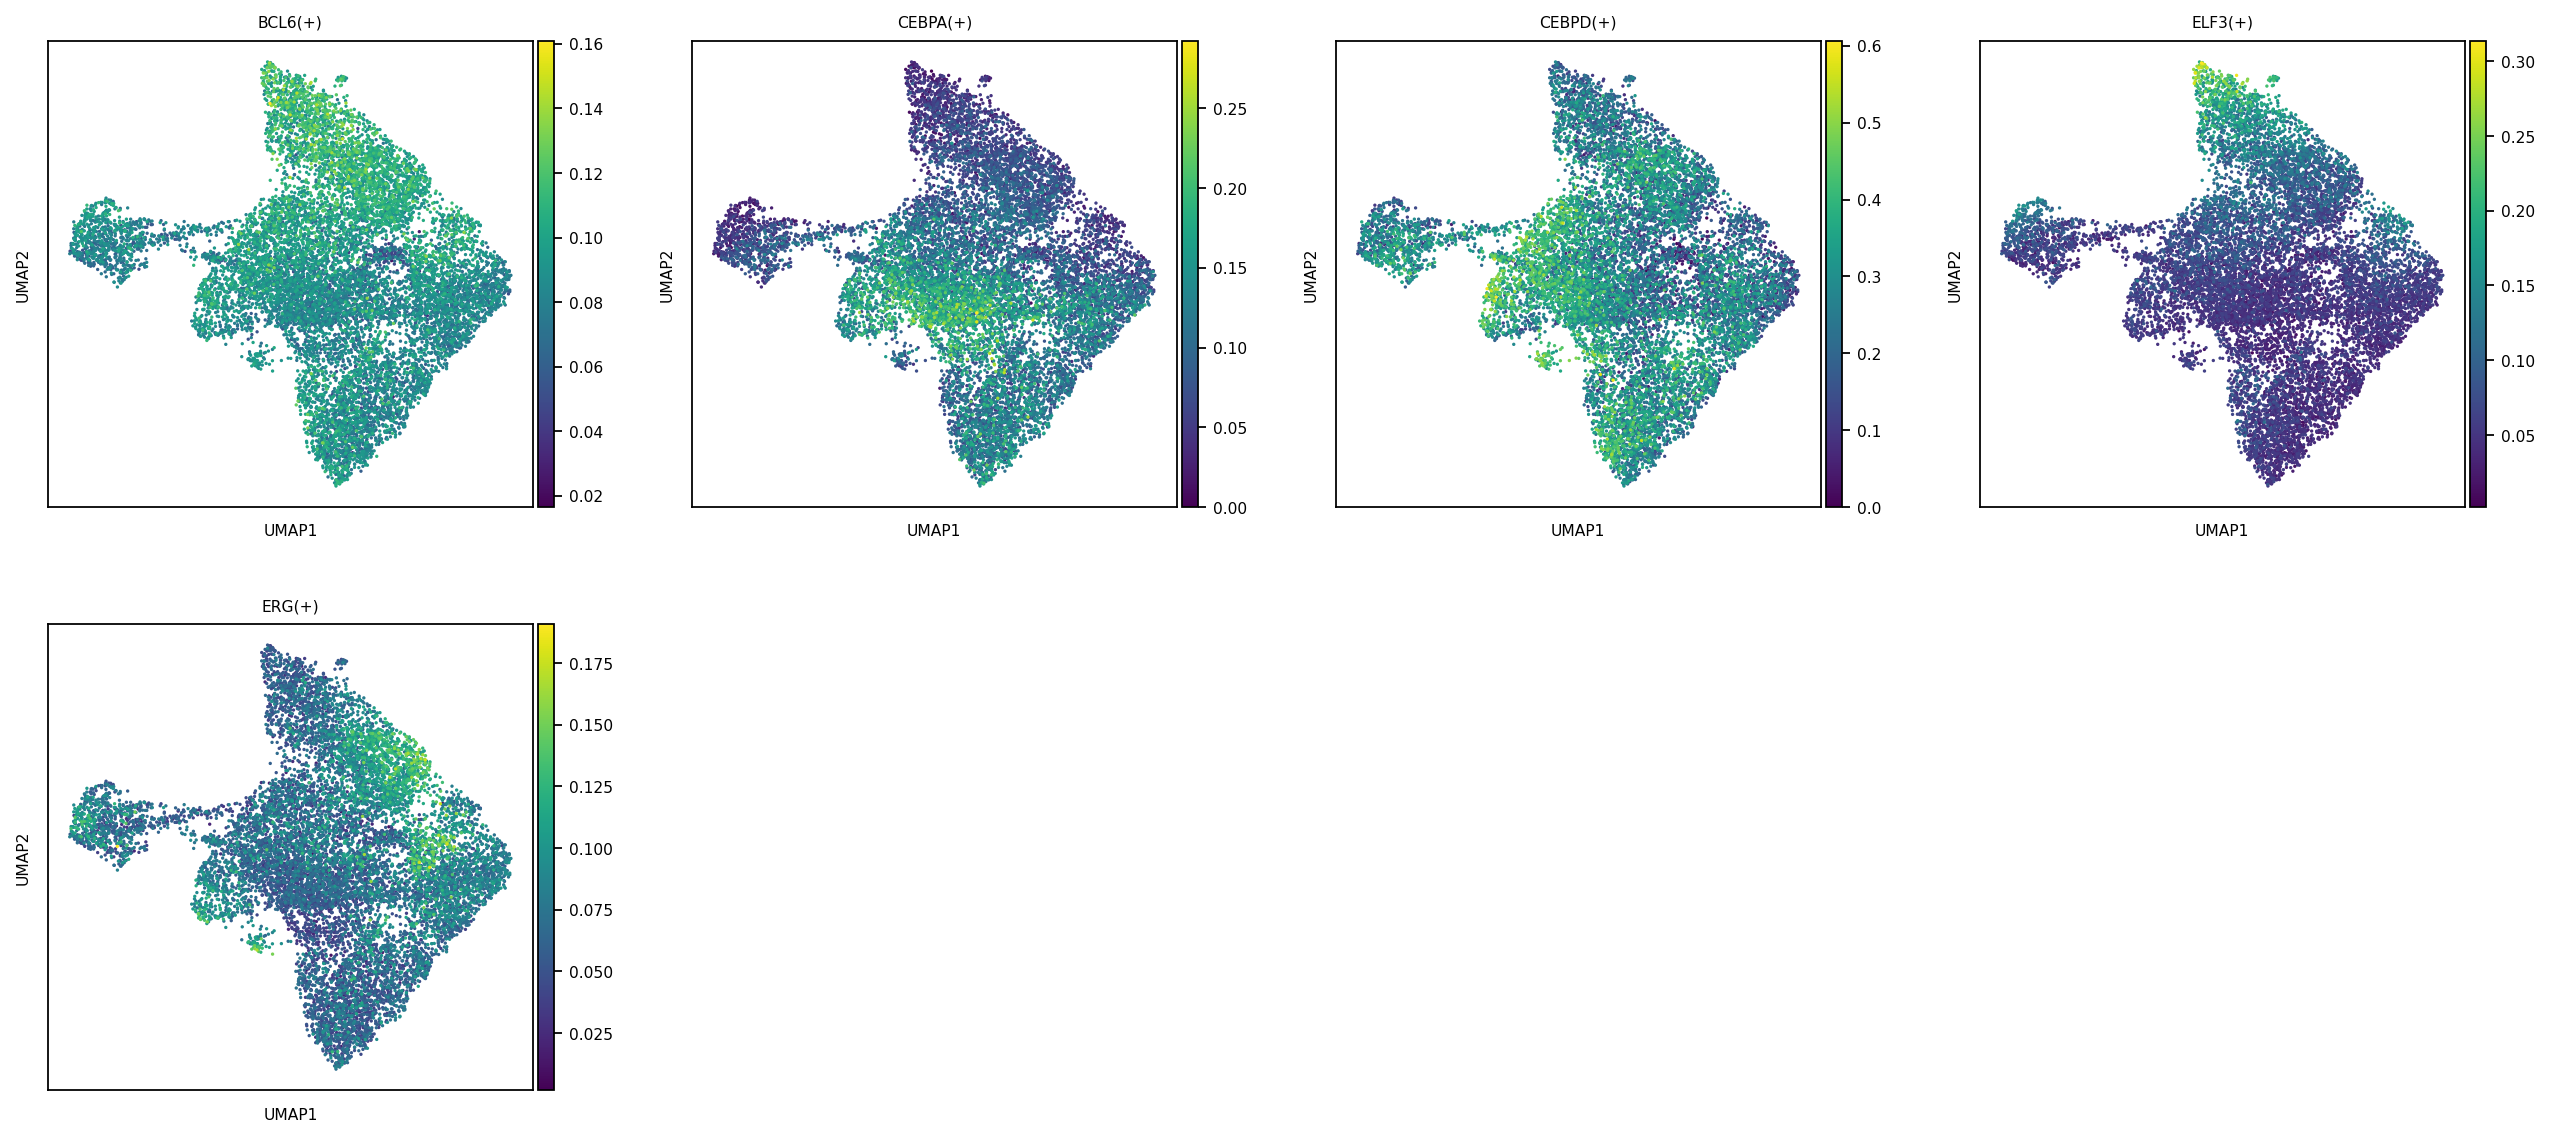

In [32]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=auc_df.columns[:5])

In [33]:
print(auc_df.columns)

Index(['BCL6(+)', 'CEBPA(+)', 'CEBPD(+)', 'ELF3(+)', 'ERG(+)', 'ETS2(+)',
       'FOSB(+)', 'FOSL2(+)', 'GATA2(+)', 'HMGA1(+)', 'HSF4(+)', 'IKZF1(+)',
       'IRF5(+)', 'JUN(+)', 'KLF4(+)', 'LTF(+)', 'MAF(+)', 'MAFB(+)',
       'MYBL2(+)', 'NANOG(+)', 'NFE2(+)', 'NFE2L3(+)', 'NKX3-1(+)', 'OSR1(+)',
       'RAX(+)', 'REL(+)', 'SOX10(+)', 'SOX4(+)', 'SPI1(+)', 'TBX18(+)',
       'TFAP2A(+)', 'TFAP2C(+)', 'ZBTB12(+)', 'ZNF449(+)'],
      dtype='object')


In [39]:
top_tfs_cleaned = [gene.split('(')[0] for gene in top_tfs]
auc_df.columns = [col.split('(')[0] for col in auc_df.columns]

top_tfs = auc_df.select_dtypes(include=[np.number]).mean(numeric_only=True).sort_values(ascending=False).index[:40]


tf_expr = pd.DataFrame(adata[:, top_tfs].X.toarray(), 
                       index=adata.obs.index, 
                       columns=top_tfs)


top_tfs_cleaned = [gene.split('(')[0] for gene in top_tfs]
auc_df.columns = [col.split('(')[0] for col in auc_df.columns]


tf_expr["leiden"] = adata.obs["leiden"].astype(str) 
tf_expr_avg = tf_expr.groupby("leiden").mean(numeric_only=True).T  


auc_df["leiden"] = adata.obs["leiden"].astype(str)  
auc_avg = auc_df.groupby("leiden").mean(numeric_only=True).T  


print("TF 平均表达（按 Leiden）:")
display(tf_expr_avg)

print("\nRegulon 活性平均值（按 Leiden）:")
display(auc_avg)

tf_expr_avg.to_csv("TF_expression_by_leiden.csv")
auc_avg.to_csv("Regulon_AUC_by_leiden.csv")

TF 平均表达（按 Leiden）:


leiden,0,1,2,3,4
JUN,0.248256,-0.210883,-0.287743,0.036015,-0.048474
CEBPD,0.149580,-0.179766,-0.292425,0.126802,0.178684
FOSB,0.045271,-0.307128,-0.192007,0.190141,0.736280
OSR1,0.057036,-0.255513,0.084194,0.171820,-0.155618
SOX4,0.001297,0.402972,-0.263487,-0.273017,0.048440
SOX10,-0.014906,-0.018976,-0.010101,-0.009921,-0.008026
KLF4,0.017231,-0.365983,0.355097,-0.109124,0.440272
FOSL2,-0.195154,0.069878,-0.078883,0.368001,0.133189
HMGA1,-0.100473,0.350230,-0.098004,-0.160670,0.068495
CEBPA,0.119292,-0.180492,-0.154385,0.187728,-0.152062



Regulon 活性平均值（按 Leiden）:


leiden,0,1,2,3,4
BCL6,0.082634,0.101285,0.081861,0.082256,0.078529
CEBPA,0.123262,0.061958,0.090328,0.106937,0.056104
CEBPD,0.271065,0.227437,0.209450,0.274384,0.250731
ELF3,0.054514,0.112105,0.055612,0.046259,0.066373
ERG,0.061302,0.081438,0.079874,0.059171,0.069112
ETS2,0.055036,0.077226,0.031816,0.046163,0.190555
FOSB,0.241634,0.184656,0.192498,0.210664,0.352054
FOSL2,0.075366,0.136159,0.106898,0.140267,0.067486
GATA2,0.036368,0.042417,0.039545,0.032813,0.024637
HMGA1,0.079651,0.190817,0.078146,0.065209,0.104527
